# RED NEURONAL CONVOLUCIONAL PARA CLASIFICACIÓN DE IMAGENES DE PERROS Y GATOS
## DATASET [KAGGLE](https://www.kaggle.com/competitions/dogs-vs-cats/overview)

# 1 - GARGAMOS IMAGENES PARA EL DATASET

## IMPORTAMOS LIBRERIAS

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## CARGAMOS PATH DE IMAGENES

In [5]:
base_dir = '/content/drive/MyDrive/Colab Notebooks/DEEP-LEARNING/datasets'
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir,'validation')
test_dir = os.path.join(base_dir,'test')
print(train_dir)
print(validation_dir)
print(test_dir)

/content/drive/MyDrive/Colab Notebooks/DEEP-LEARNING/datasets/train
/content/drive/MyDrive/Colab Notebooks/DEEP-LEARNING/datasets/validation
/content/drive/MyDrive/Colab Notebooks/DEEP-LEARNING/datasets/test


## CREO LOS DIRECTORIOS PARA CADA CONJUNTO DE DATOS DE PERROS Y GATOS

In [6]:
train_gatos_dir = os.path.join(train_dir, 'gatos')
train_perros_dir = os.path.join(train_dir, 'perros')

validation_gatos_dir = os.path.join(validation_dir, 'gatos')
validation_perros_dir = os.path.join(validation_dir, 'perros')

test_gatos_dir = os.path.join(test_dir, 'gatos')
test_perros_dir = os.path.join(test_dir, 'perros')

print(train_gatos_dir)
print(train_perros_dir)
print(validation_gatos_dir)
print(validation_perros_dir)
print(test_gatos_dir)
print(test_perros_dir)

/content/drive/MyDrive/Colab Notebooks/DEEP-LEARNING/datasets/train/gatos
/content/drive/MyDrive/Colab Notebooks/DEEP-LEARNING/datasets/train/perros
/content/drive/MyDrive/Colab Notebooks/DEEP-LEARNING/datasets/validation/gatos
/content/drive/MyDrive/Colab Notebooks/DEEP-LEARNING/datasets/validation/perros
/content/drive/MyDrive/Colab Notebooks/DEEP-LEARNING/datasets/test/gatos
/content/drive/MyDrive/Colab Notebooks/DEEP-LEARNING/datasets/test/perros


## PROBAMOS LA CARGA DE IMAGENES ALEATORIAS DE PERROS Y GATOS

In [7]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def mostrar_imagenes_aleatorias(directorio, num_imagenes=5):
    # Obtener lista de archivos de imagen en el directorio
    imagenes = os.listdir(directorio)

    # Filtrar archivos para obtener solo las imágenes (por ejemplo, con extensiones jpg o png)
    imagenes = [img for img in imagenes if img.endswith(('.jpg', '.jpeg', '.png'))]

    # Seleccionar imágenes aleatorias
    imagenes_aleatorias = random.sample(imagenes, min(num_imagenes, len(imagenes)))

    # Mostrar las imágenes seleccionadas
    for img_name in imagenes_aleatorias:
        img_path = os.path.join(directorio, img_name)
        img = mpimg.imread(img_path)

        plt.figure()
        plt.imshow(img)
        plt.title(img_name)
        plt.axis('off')  # Ocultar los ejes
        plt.show()

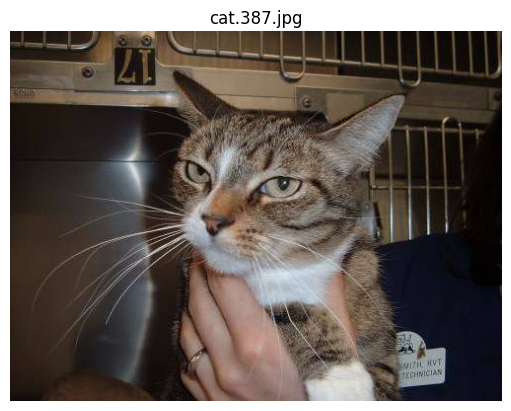

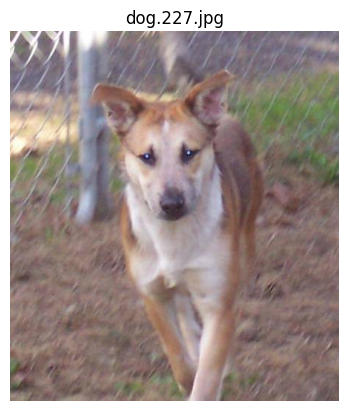

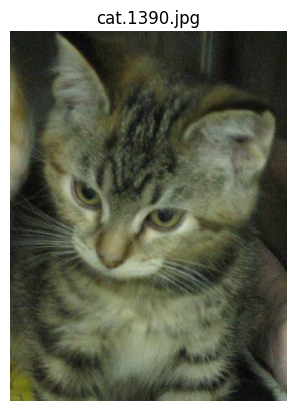

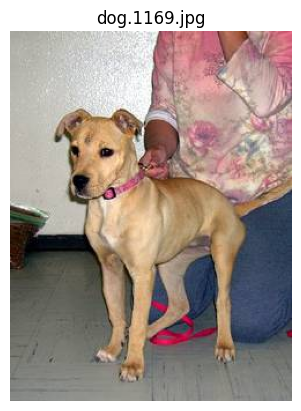

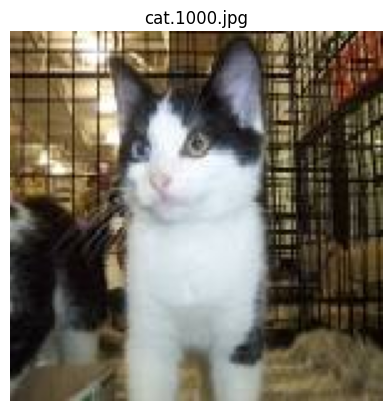

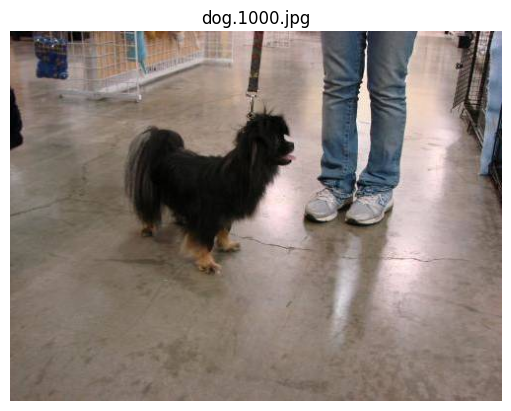

In [12]:
dataset_dir = [train_gatos_dir,train_perros_dir,validation_gatos_dir,validation_perros_dir,test_gatos_dir,test_perros_dir]
for img_dir in dataset_dir:
  mostrar_imagenes_aleatorias(img_dir,num_imagenes=1)

## Mostramos que cantidades de archivos hay en cada carpeta

In [13]:
for img_dir in dataset_dir:
  print(f" en directorio :{img_dir} hay {len(os.listdir(img_dir))} imagenes")

 en directorio :/content/drive/MyDrive/Colab Notebooks/DEEP-LEARNING/datasets/train/gatos hay 1000 imagenes
 en directorio :/content/drive/MyDrive/Colab Notebooks/DEEP-LEARNING/datasets/train/perros hay 1000 imagenes
 en directorio :/content/drive/MyDrive/Colab Notebooks/DEEP-LEARNING/datasets/validation/gatos hay 500 imagenes
 en directorio :/content/drive/MyDrive/Colab Notebooks/DEEP-LEARNING/datasets/validation/perros hay 500 imagenes
 en directorio :/content/drive/MyDrive/Colab Notebooks/DEEP-LEARNING/datasets/test/gatos hay 1 imagenes
 en directorio :/content/drive/MyDrive/Colab Notebooks/DEEP-LEARNING/datasets/test/perros hay 1 imagenes


# 2 - CONVERTIMOS NUESTAS IMAGENES EN UN ARRAY DE DATOS

In [18]:
from keras.preprocessing import image
import matplotlib.pyplot as plt
fnames = [os.path.join(train_perros_dir, fname) for
          fname in os.listdir(train_perros_dir)]
img_path = fnames[1]
img = image.load_img(img_path, target_size=(64, 64))
#comvertimos a un arreglo Numpy de (150, 150, 3)
x = image.img_to_array(img)
x

array([[[117., 115., 128.],
        [142., 141., 149.],
        [160., 161., 166.],
        ...,
        [151., 153., 165.],
        [138., 140., 152.],
        [134., 137., 146.]],

       [[122., 120., 133.],
        [144., 143., 151.],
        [159., 160., 165.],
        ...,
        [154., 156., 168.],
        [148., 150., 162.],
        [139., 142., 151.]],

       [[128., 126., 139.],
        [143., 142., 150.],
        [165., 166., 171.],
        ...,
        [158., 160., 172.],
        [148., 150., 162.],
        [143., 147., 156.]],

       ...,

       [[169., 162., 230.],
        [102.,  82., 119.],
        [100.,  93., 109.],
        ...,
        [ 81.,  89.,  92.],
        [ 69.,  79.,  81.],
        [ 62.,  72.,  74.]],

       [[ 65.,  74.,  83.],
        [ 80.,  88.,  90.],
        [ 69.,  80.,  76.],
        ...,
        [ 63.,  71.,  74.],
        [ 66.,  76.,  78.],
        [ 57.,  67.,  69.]],

       [[ 72.,  77.,  81.],
        [ 64.,  75.,  77.],
        [ 74.,  

## COMPROBAMOS LA IMAGEN DESDE EL ARRAY

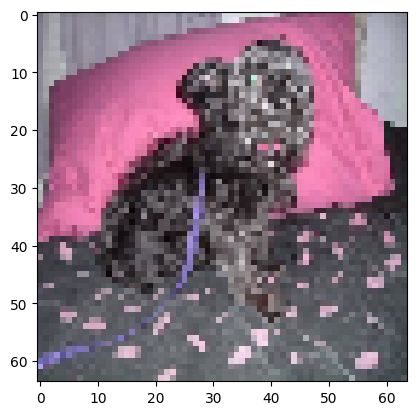

In [19]:
plt.figure()
imgplot = plt.imshow(image.array_to_img(x))
plt.show()

# 3 - CREAMOS OBJETOS PARA CARGAR EL CONJUNTO DE ENTRENAMIENTO VALIDACIÓN Y PRUEBAS

In [23]:
import tensorflow as tf
print(tf.__version__)

2.18.0


In [22]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_data = ImageDataGenerator(rescale=1. /255)
val_data = ImageDataGenerator(rescale=1. /255)
test_data = ImageDataGenerator(rescale=1. /255)

## CARGAMOS LOS CONJUNTOS DE DATOS CON LOS OBJETOS CREADOS

In [24]:
training_set = train_data.flow_from_directory(
    train_dir,
    target_size=(64,64),
    batch_size=32,
    class_mode='binary'
)
validation_set = train_data.flow_from_directory(
    validation_dir,
    target_size=(64,64),
    batch_size=20,
    class_mode='binary'
)
test_set = train_data.flow_from_directory(
    test_dir,
    target_size=(64,64),
    class_mode='binary'
)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 2 images belonging to 2 classes.


# 4 - CREAMOS MODELO DE RED NEURONAL CONVOLUCIONAL

In [27]:
from keras.models import Sequential
from keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout

modelo = Sequential()
modelo.add(Conv2D(32,(3,3),activation='relu',input_shape=(64,64,3)))
modelo.add(MaxPooling2D((2,2)))
modelo.add(Conv2D(32,(3,3),activation='relu'))
modelo.add(MaxPooling2D((2,2)))
modelo.add(Flatten())
modelo.add(Dense(128,activation='relu'))
modelo.add(Dropout(0.5))
modelo.add(Dense(1,activation='sigmoid'))

modelo.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)                    │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 29, 29, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         802,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 813,217 (3.10 MB)

 Trainable params: 813,217 (3.10 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
modelo.compile(loss="binary_crossentropy",
               optimizer='adam',
               metrics=['accuracy'])

In [ ]:
history = modelo.fit(training_set,epochs=1,batch_size=100,validation_data=validation_set)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


36/63 ━━━━━━━━━━━━━━━━━━━━ 11:01 24s/step - accuracy: 0.4926 - loss: 0.7120

# EVALUAMOS EL MODELO

In [ ]:
evaluacion = modelo.evaluate(test_set)
print(evaluacion)

# REALIZAMOS PREDICCIÓN DEL MODELO

In [ ]:
gato = image.load_img(test_gatos_dir + "\\cat.1000.jpg",target_size=(64,64))

test_image = image.img_to_array(gato)
test_image = np.expand_dims(test_image,axis=0)

training_set.class_indices

result = modelo.predict(test_image)

if result[0][0] == 0:
  print("Es un gato")
else:
  print("Es un perro")